### Tarea 2 Gustavo Lara Urrutia - Data Analysis And Machine Learning S1 2025

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

from linearmodels import PooledOLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
df = pd.read_csv(r"C:\Users\gusta\OneDrive\Escritorio\Saberes\Asignaturas Ing. Civil Industrial\Data Analysis and Machine Learning\Tarea 2\panel_eps.csv")
df.head

<bound method NDFrame.head of           folio_n20  year  time  edad  hombre   edu  region  status  kids  \
0      124560204870     4     2    49     0.0   7.0     5.0     3.0     1   
1      124560204870     6     3    51     0.0   4.0     5.0     3.0     1   
2      124560204870     9     4    54     0.0   5.0     5.0     3.0     1   
3      124560204870    12     5    57     0.0   4.0     NaN     5.0     0   
4      124560205935     2     1  1982     0.0  15.0    13.0     3.0     1   
...             ...   ...   ...   ...     ...   ...     ...     ...   ...   
96841  128133653188    12     5  1992     0.0  16.0     NaN     3.0     0   
96842  128133692735    12     5  1992     0.0  12.0     NaN     2.0     0   
96843  128133702320    12     5  1992     0.0  15.0     NaN     5.0     0   
96844  128133728022    12     5  1992     0.0   8.0     NaN     2.0     0   
96845  128133731927    12     5  1992     1.0   8.0     NaN     2.0     0   

       children  ...  fondob  fondoc  fondod 

In [3]:
df.dtypes

folio_n20       int64
year            int64
time            int64
edad            int64
hombre        float64
edu           float64
region        float64
status        float64
kids            int64
children      float64
situation       int64
lmp             int64
exp           float64
size          float64
occupation    float64
wage          float64
hours         float64
informal      float64
selfemp       float64
publicemp     float64
sistema       float64
cotizando     float64
assets        float64
fondoa        float64
fondob        float64
fondoc        float64
fondod        float64
fondoe        float64
exp_sist        int64
expectancy    float64
illness       float64
cronica       float64
nocronica     float64
mental        float64
dtype: object

Se convierten las variables categóricas. 

In [4]:
categorical_vars = ["hombre", "region", "status", "kids", "situation", "lmp", "informal", 
                    "selfemp", "publicemp", "sistema", "cotizando", "illness", "cronica", 
                    "nocronica", "mental"]
df[categorical_vars] = df[categorical_vars].astype("category")


In [5]:
print(df.dtypes)

folio_n20        int64
year             int64
time             int64
edad             int64
hombre        category
edu            float64
region        category
status        category
kids          category
children       float64
situation     category
lmp           category
exp            float64
size           float64
occupation     float64
wage           float64
hours          float64
informal      category
selfemp       category
publicemp     category
sistema       category
cotizando     category
assets         float64
fondoa         float64
fondob         float64
fondoc         float64
fondod         float64
fondoe         float64
exp_sist         int64
expectancy     float64
illness       category
cronica       category
nocronica     category
mental        category
dtype: object


Transformación de variable Edad para que sea coherente con los datos:

In [ ]:
df["year_completo"] = df["year"] + 2000

df = df.sort_values(["folio_n20", "year_completo"])

df["primer_year"] = df.groupby("folio_n20")["year_completo"].transform("first")
df["primer_edad_raw"] = df.groupby("folio_n20")["edad"].transform("first")  

df["edad_inicial"] = df.apply(
    lambda x: x["primer_year"] - x["primer_edad_raw"] if (x["primer_edad_raw"] >= 1900) & (x["primer_edad_raw"] <= x["primer_year"]) 
    else x["primer_edad_raw"],
    axis=1
)


df["edad_corregida"] = df["edad_inicial"] + (df["year_completo"] - df["primer_year"])

df["edad_corregida"] = df["edad_corregida"].clip(lower=0, upper=120) 

In [7]:
df["edad"] = df["edad_corregida"]
df = df.drop(columns=["primer_year", "primer_edad_raw", "edad_inicial", "edad_corregida"])

Se eliminan los NaN para 'Expectancy':

In [ ]:
df["expectancy"] = df["expectancy"].apply(lambda x: x if 0 < x < 120 else None)

In [9]:
df = df[~df["expectancy"].isnull()]

In [10]:
df = df[~df["assets"].isnull()]

Se eliminan filas sin datos o con más de 60% de datos faltantes. 

In [ ]:
df = df.drop(['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe'], axis=1)
df = df.loc[:, df.isnull().mean() < 0.6]

Imputar 'region' usando el valor más frecuente (moda) de cada individuo

In [12]:
df["region"] = df.groupby("folio_n20")["region"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

Si 'Kids' = 0, entonces 'Children' = 0

In [13]:
df.loc[df["kids"] == 0, "children"] = 0

'Occupation' se imputa por la moda, las personas que no informaron ocupación se les crea una nueva categoria y se asigna como valor 11. 

In [14]:
df["occupation"] = df.groupby("folio_n20")["occupation"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

In [15]:
df["occupation"] = df["occupation"].fillna(11)


In [16]:
df["occupation"] = df["occupation"].astype("category")

Para 'assets' se imputa por la media por grupo, en este caso por cada individuo (n° de folio). Finalmente se eliminan los valores nulos. 

In [17]:
df["assets"] = df.groupby(["folio_n20"])["assets"].transform(lambda x: x.fillna(x.median()))


Se imputa por moda o media para el resto de variables con bajo porcentaje de NaN (y por sentido lógico, es difícil que cambien entre rondas)

In [18]:
df["hombre"] = df.groupby("folio_n20")["hombre"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
df["edu"] = df.groupby("folio_n20")["edu"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
df["region"] = df.groupby("folio_n20")["region"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)


In [19]:
df = df[df['status'].notna()]
df = df[df['region'].notna()]


Se hace imputacion por moda siguiendo numero de folio a variables como 'Informal', 'Selfemp' y 'publicemp', debido a que tienen más de 30% de NaN.

In [20]:
df["informal"] = df.groupby("folio_n20")["informal"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
df["selfemp"] = df.groupby("folio_n20")["selfemp"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
df["publicemp"] = df.groupby("folio_n20")["publicemp"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

Si alguien cotiza, entonces también participa del sistema. Además, una vez en el sistema, es poco probable abandonar el sistema. 

In [21]:
df.loc[df["cotizando"] == 1, "sistema"] = 1

In [22]:
df["sistema"] = df.groupby("folio_n20")["sistema"].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

Se realiza imputacion KNN para la variable 'Wage', se dejan solo los salarios menores a 3 millones. 

In [ ]:
print(f"Registros originales: {len(df)}")

df = df[df['wage'].lt(3_000_000) | df['wage'].isna()]

print(f"Registros filtrados: {len(df)}")
print(f"NaN conservados: {df['wage'].isna().sum()}")

Registros originales: 53371
Registros filtrados: 53307
NaN conservados: 21964


In [24]:
from sklearn.impute import KNNImputer

In [ ]:
cols = ["wage", "edu", "edad", "assets", "exp", "occupation", "kids", "region", "hombre"]
knn_data = df[cols].copy()

imputer = KNNImputer(n_neighbors=5)

knn_result = imputer.fit_transform(knn_data)

df_knn = pd.DataFrame(knn_result, columns=cols)


In [26]:
df["wage"] = pd.Series(df_knn["wage"].values, index=df.index)


In [ ]:
print(df["wage"].isnull().sum())


0


In [28]:
df_original = pd.read_csv(r"C:\Users\gusta\OneDrive\Escritorio\Saberes\Asignaturas Ing. Civil Industrial\Data Analysis and Machine Learning\Tarea 2\panel_eps.csv")

Se observa una reducción considerable de datos nulos en el dataset.

<Axes: >

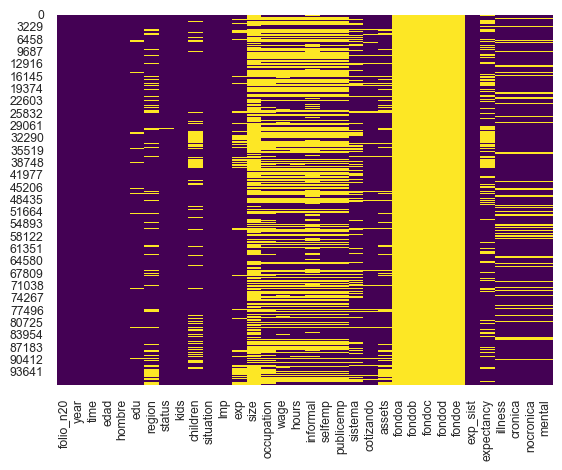

In [120]:
sns.heatmap(df_original.isnull(), cbar=False, cmap="viridis")

<Axes: >

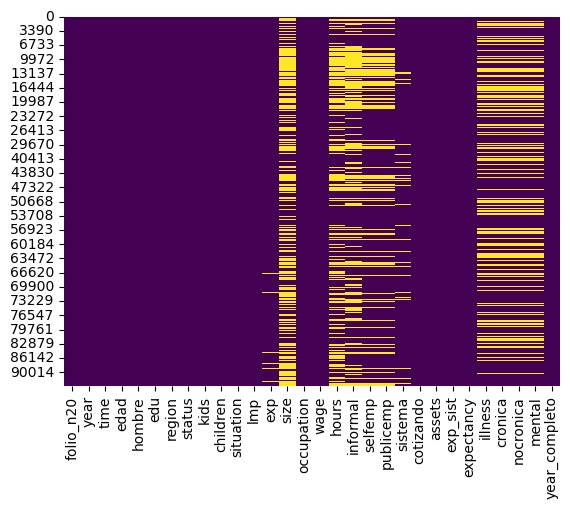

In [ ]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

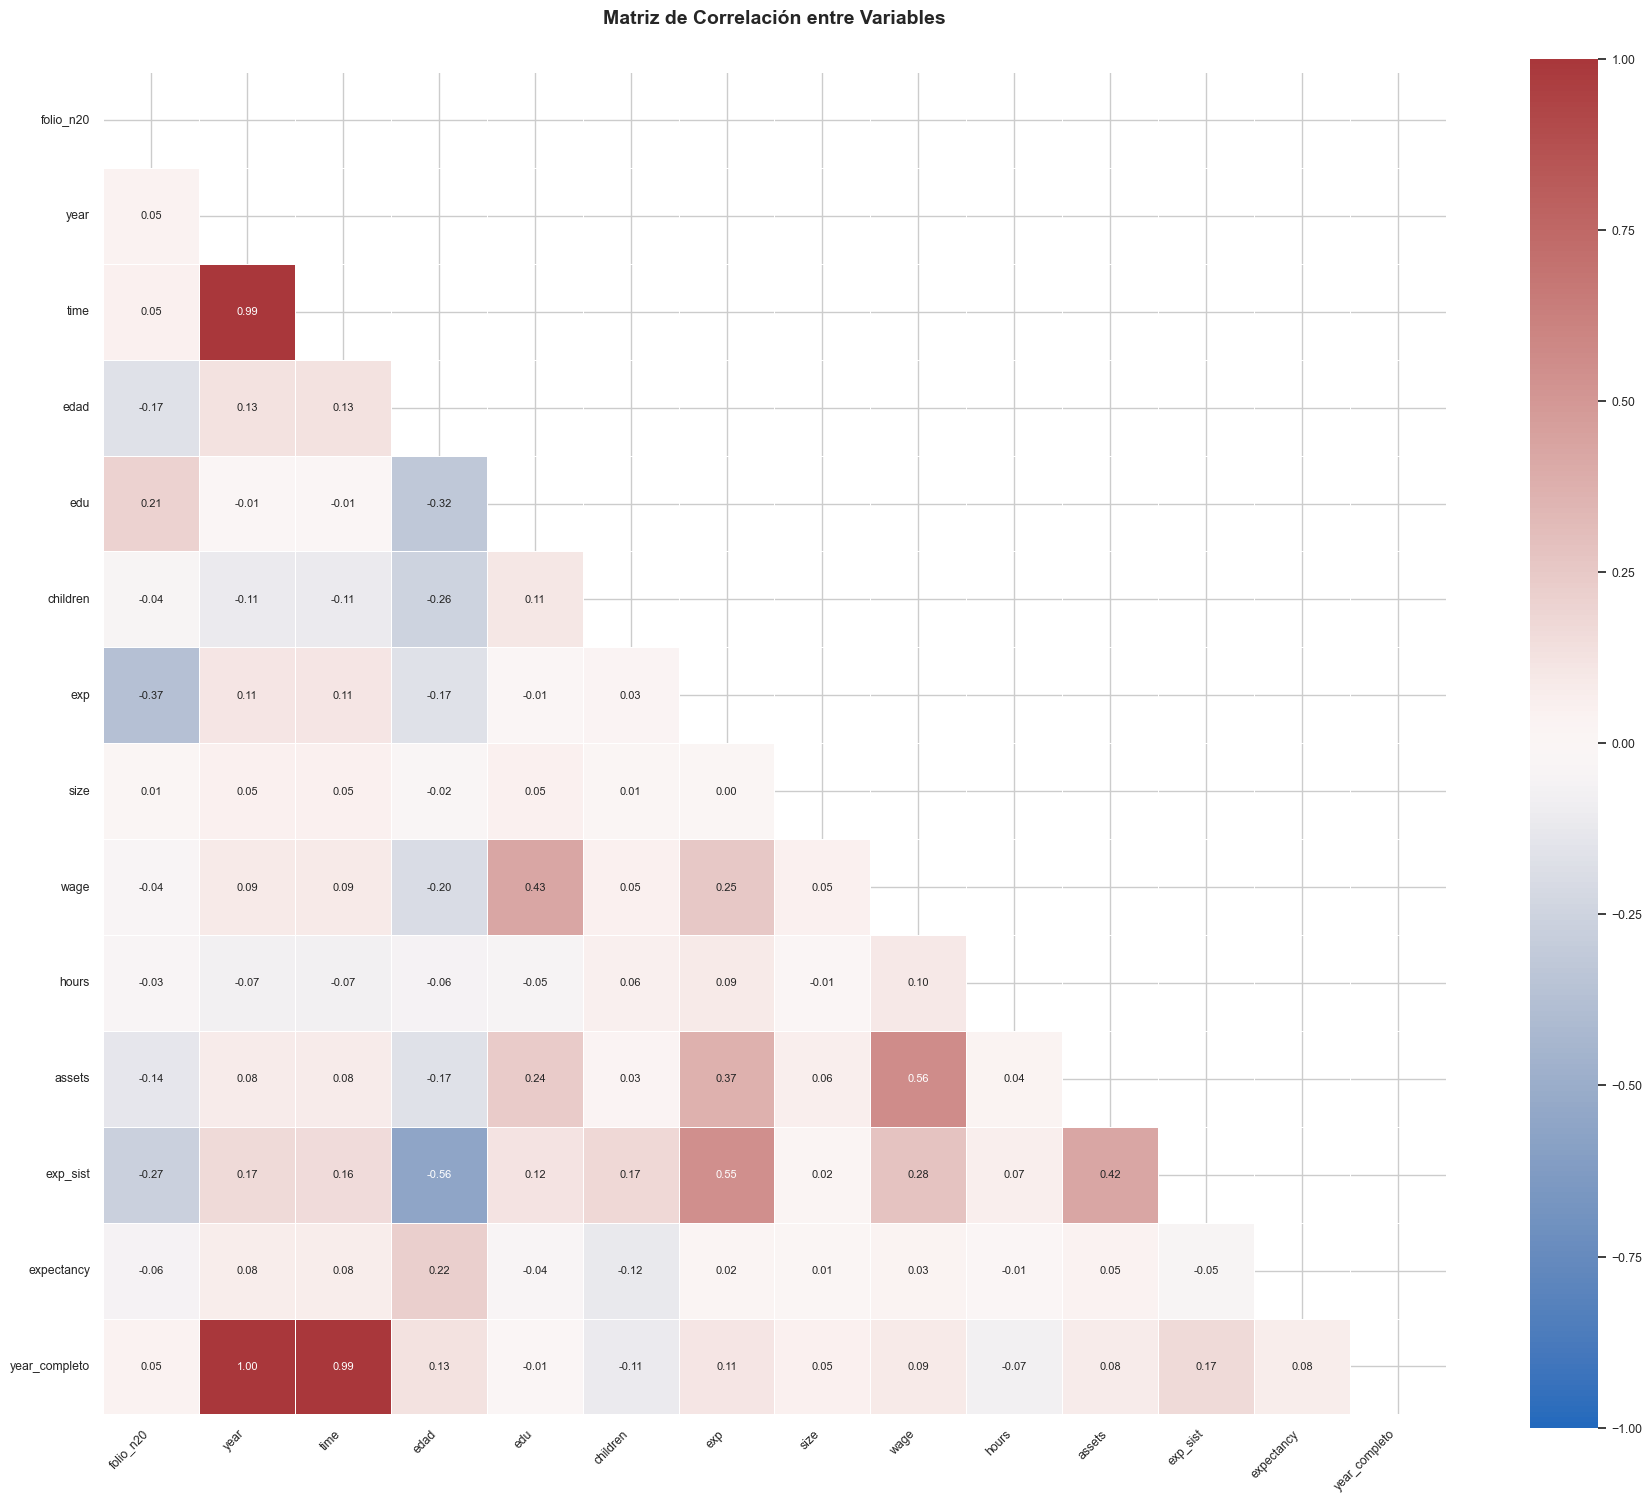

In [ ]:
sns.set_theme(style="whitegrid", font_scale=0.8)

numeric_vars = df.select_dtypes(include=np.number).columns.tolist()

corr_matrix = df[numeric_vars].corr(method="pearson")


plt.figure(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    square=True
)


plt.title("Matriz de Correlación entre Variables\n", fontsize=14, fontweight="bold", pad=20)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha="right")
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)


plt.tight_layout()
plt.show()

In [31]:
df_copy = df

2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

R: Para realizar el modelo, se excluyeron variables de baja significancia, alta cantidad de datos nulos tras la limpieza (como 'size') o que presentaran una alta colinealidad ('edad' es una función lineal dependiente del tiempo). El resultado obtenido fue el de un r cuadrado de 0.0012, es decir, el modelo de datos agrupados explica cerca del 0.12% de la variabilidad de la expectativa de vida autorreportada. Si bien este valor es bajo, es común en variables de percepción o autorreporte, donde gran parte de la variabilidad está determinada por factores no observados, subjetivos o psicológicos.

Algunas variables presentan relaciones estadísticamente significativas y consistentes con la literatura, como tener hijos ('kids') se asocia a una reducción significativa en la expectativa (-1.95 años), posiblemente por la percepción de mayores responsabilidades o desgaste; o como la experiencia laboral (exp) y mayores ingresos (wage), que están positivamente relacionados con la expectativa de vida.

In [32]:
df = df.set_index(['folio_n20', 'time'])

'lmp', 'region', 

In [92]:
y = df['expectancy']

X = df[['hombre', 'edu' ,'status', 'kids','situation', 'exp', 'occupation',
        'wage', 'sistema', 'cotizando', 'assets', 'exp_sist','cronica']]

In [ ]:
X = pd.get_dummies(X, columns=['status', 'situation', 'occupation', 'sistema'], drop_first=True)
X = sm.add_constant(X)

In [94]:
model = PooledOLS(y, X, check_rank=False)  # Opción para evitar el error
mco = model.fit(cov_type="robust")

In [96]:
print(mco.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                        0.0646
Estimator:                  PooledOLS   R-squared (Between):              0.1047
No. Observations:               51561   R-squared (Within):               0.0013
Date:                Tue, May 20 2025   R-squared (Overall):              0.0646
Time:                        21:29:32   Log-likelihood                -1.937e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      131.84
Entities:                       19022   P-value                           0.0000
Avg Obs:                       2.7106   Distribution:                F(27,51533)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             141.49
                            

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

R: El modelo de efectos fijos explica un 2.1% de la variación de la expectativa de vida dentro de cada individuo en el tiempo. Aunque bajo, es esperado en variables subjetivas y con alta heterogeneidad individual. 

Es importante destacar que la configuración del modelo fue tal que se eliminaron aquellas variables que son constantes para cada individuo o perfectamente colineadas con otras variables constantes (entity_effects=True). Esto incluye, por ejemplo, variables como 'hombre' (sexo), 'edu' (años de educación), y 'occupation', las cuales tienden a mantenerse estables en el tiempo y, por tanto, no pueden ser identificadas en un modelo de efectos fijos.

En el modelo resultaron tres variables significativas:

- Experiencia laboral (exp): Mayor experiencia laboral se asocia a una mayor expectativa de vida. Esto podría estar reflejando mayor estabilidad económica o autoestima.

- Ingreso (wage): Aunque es significativa, el efecto estimado sobre la expectativa es cercana a cero. 

- Años en el sistema de pensiones (exp_sist): Quienes acumulan más años en el sistema previsional reportan una expectativa de vida mayor, lo que puede reflejar una percepción de futuro más segura.



In [ ]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

X = df[[ 'edu' ,'status', 'kids','situation', 'exp', 'occupation',
        'wage', 'sistema', 'cotizando', 'assets', 'exp_sist','cronica',
        'informal']]
X = pd.get_dummies(X, columns=['status', 'situation', 'occupation', 'sistema'], drop_first=True)
X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe = model.fit(cov_type="robust")
print(fe.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0209
Estimator:                   PanelOLS   R-squared (Between):             -0.2556
No. Observations:               51561   R-squared (Within):               0.0209
Date:                Tue, May 20 2025   R-squared (Overall):             -0.1527
Time:                        23:01:15   Log-likelihood                -1.706e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      63.264
Entities:                       19022   P-value                           0.0000
Avg Obs:                       2.7106   Distribution:                F(11,32528)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             55.049
                            

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

R: A diferencia del modelo de efectos fijos, este modelo permite incluir variables que no cambian en el tiempo para cada individuo (como sexo, educación o estatus ocupacional), bajo el supuesto de que las diferencias individuales no observadas no están correlacionadas con las variables explicativas. Se observa que el modelo explica un 6.3% de la variabilidad total de la expectativa de vida. 

- Variables como educación y enfermedad crónica no son estadísticamente significativas. 
- 'hombre' es significativa, reportando en promedio 1.5 años más de expectativa de vida que las mujeres, lo cual contrasta con evidencia empírica real y sugiere un sesgo perceptual más que objetivo.
- Tener hijos ('kids') se asocia con una menor expectativa de vida autorreportada, posiblemente por percepciones de carga o estrés.
- Variables económicas como 'exp', 'wage', 'assets' y 'exp_sist' son positivas y significativas, lo que señala que la estabilidad financiera y la experiencia previsional se relacionan positivamente con la expectativa de vida.
- Cotizar en el sistema ('cotizando') sugiere que el estar contribuyendo activamente al sistema de pensiones mejora la expectativa de vida percibida, quizás por sensación de seguridad futura.
- Sobre la ocupación no informada ('occupation_11.0) se observa que tiene un coeficiente alto de 1.17 y alta significancia. Esto podría tener dos explicaciones: que aquí se incluyen personas fuera de la fuerza laboral (jubilación, enfermedad o informalidad) que no perciben su situación como negativa, o que quienes no quisieron responder lo hicieron por desinterés o que no encajaban dentro de las categorías dadas (labor doméstica, trabajo no remunerado). Es importante notar el efecto estadístico, ya que esta variable podría agrupar grupos claramente heterogéneos, de modo que se concentren e "inflen" la expectativa de vida autorreportada.  



In [38]:
from linearmodels.panel import RandomEffects

X = df[['hombre', 'edu', 'status', 'kids', 'situation', 'exp', 'occupation',
        'wage', 'sistema', 'cotizando', 'assets', 'exp_sist', 'cronica']]
X = pd.get_dummies(X, columns=['status', 'situation', 'occupation', 'sistema'], drop_first=True)
X = sm.add_constant(X)

y = df["expectancy"]

model = RandomEffects(y, X)
re = model.fit(cov_type="robust")

print(re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.2863
Estimator:              RandomEffects   R-squared (Between):              0.0992
No. Observations:               51561   R-squared (Within):               0.0070
Date:                Tue, May 20 2025   R-squared (Overall):              0.0632
Time:                        16:11:28   Log-likelihood                -1.827e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      765.58
Entities:                       19022   P-value                           0.0000
Avg Obs:                       2.7106   Distribution:                F(27,51533)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             93.059
                            

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

R: Como se puede observar del test de Hausmann, el valor p es de 0.000, lo que indica evidencia estadísticamente significativa de que los coeficientes de ambos modelos difieren. Esto sugiere que los efectos individuales no observados están correlacionados con las variables explicativas, por lo que el supuesto del modelo RE se viola. En consecuencia, el modelo de efectos fijos resulta más adecuado si se desea obtener estimadores consistentes. No obstante, el modelo de efectos fijos elimina automáticamente variables que son constantes en el tiempo (como 'hombre' o 'edu'), lo cual limita su capacidad explicativa, cuyo foco es precisamente entender el impacto de años de educación sobre la expectativa de vida.

En cuanto a robustez, algunas variables mantuvieron significancia y signo consistente a través de los tres modelos:

- 'experiencia laboral' (exp) y experiencia en el sistema de pensiones (exp_sist) fueron positivas y significativas.

- 'cotizando' (ser cotizante) también mostró un efecto positivo robusto.

- 'cronica' (tener enfermedad crónica) fue significativa y negativa en los modelos Pooled y CRE, aunque no en FE o RE.

- 'status_4.0' (ser viudo/a) mostró un efecto fuertemente positivo y robusto.

En cambio, la variable edu no fue significativa en ningún modelo, incluso cuando se incluyó directamente en Pooled y RE, lo cual sugiere que no hay evidencia clara de una relación directa entre años de educación y la expectativa de vida autorreportada, al menos con esta especificación y muestra.

In [71]:
common = fe.params.index.intersection(re.params.index)
diff = fe.params[common] - re.params[common]
psi = fe.cov.loc[common, common] - re.cov.loc[common, common]


W = diff.T @ la.inv(psi.values) @ diff
dof = len(diff)
pval = stats.chi2.sf(W, dof)
print(f"Hausman Test: chi2 = {W:.4f}, df = {dof}, p-value = {pval:.4f}")


Hausman Test: chi2 = 429.8492, df = 12, p-value = 0.0000


In [119]:
import linearmodels.panel as lmp

print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects      PooledOLS
No. Observations                 51561             51561          51561
Cov. Est.                       Robust            Robust         Robust
R-squared                       0.0209            0.2863         0.0646
R-Squared (Within)              0.0209            0.0070         0.0013
R-Squared (Between)            -0.2556            0.0992         0.1047
R-Squared (Overall)            -0.1527            0.0632         0.0646
F-statistic                     63.264            765.58         131.84
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

R: El R² overall es 0.0733, una mejora respecto al modelo de efectos aleatorios sin CRE (RE puro: 0.0632) y superior al modelo de efectos fijos (FE: -0.1527), lo que indica un mejor ajuste. Este resultado, aunque moderado, es esperable en modelos sociales complejos donde influyen múltiples factores no observables.

- 'exp' (experiencia laboral) fue positiva y altamente significativa  (0.1372, p < 0.05), indicando que a mayor experiencia, mayor expectativa de pensión.

- 'exp_sist' (experiencia en el sistema previsional) también mostró un efecto positivo significativo, mientras que su media (m_exp_sist) fue negativa y significativa, sugiriendo diferencias entre el efecto a nivel individual y el promedio entre personas.

- 'cronica' (enfermedad crónica) tener una enfermedad crónica se asocia con una reducción significativa en la expectativa (-0.9536, p < 0.01).

- Algunas ocupaciones (grupos 5 al 9) mostraron efectos negativos y significativos, reflejando una posible relación entre tipo de trabajo y percepción de longevidad.

- Entre las variables promedio, 'm_kids', 'm_exp', 'm_cotizando' y 'm_assets' fueron significativas, lo que indica que existen diferencias persistentes entre individuos que están relacionadas con la expectativa de vida y que se refuerza la presencia de heterogeneidad no observada.

- Los coeficientes de 'm_year_2', 'm_year_3' y 'm_year_4' son negativos y altamente significativos, lo que sugiere que existen efectos sistemáticos de tiempo que influyen en la expectativa de pensión. Esto indica que, en promedio, las expectativas son menores en esos años comparados con el año base, y que dichos efectos no estaban adecuadamente capturados en modelos anteriores sin controles temporales. En todo caso, su inclusión como dummy mejora la estimación del componente no observado.

El modelo CRE resulta adecuado, puesto que permite mantener variables relevantes que no varían en el tiempo, y al mismo tiempo controlar explícitamente por componentes no observados mediante las medias individuales. La significancia de varias de estas medias indica que efectivamente existe correlación entre las características no observadas de los individuos y las explicativas del modelo.

In [118]:
import statsmodels.api as sm
from linearmodels.panel import RandomEffects

X = df[['hombre', 'edu', 'status', 'kids', 'situation', 'exp', 'occupation',
        'wage', 'sistema', 'cotizando', 'assets', 'exp_sist', 'cronica']]
X = pd.get_dummies(X, columns=['status', 'situation', 'occupation', 'sistema'], drop_first=True)

X['year'] = df.index.get_level_values(1)
X = pd.get_dummies(X, columns=['year'], drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')

Xm = X.groupby(level=0).transform('mean')
Xm.columns = ['m_' + col for col in Xm.columns]

Xc = pd.concat([X, Xm], axis=1)
Xc = sm.add_constant(Xc)

y = df['expectancy']
Xc.index = df.index
y.index = df.index

model = RandomEffects(y, Xc, check_rank=False)
cre = model.fit(cov_type="robust")

print(cre.summary)



                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3104
Estimator:              RandomEffects   R-squared (Between):              0.1003
No. Observations:               35738   R-squared (Within):               0.0142
Date:                Tue, May 20 2025   R-squared (Overall):              0.0733
Time:                        23:23:55   Log-likelihood                -1.254e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      267.64
Entities:                       17124   P-value                           0.0000
Avg Obs:                       2.0870   Distribution:                F(60,35677)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             103.56
                            

7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

R: El gráfico muestra que el componente no observado estimado por el modelo CRE tiene una distribución mucho más estrecha que la variable dependiente observada. Esto es esperable: al eliminar el efecto de las variables observadas, el modelo solo deja lo que es constante a lo largo del tiempo para cada individuo.

La baja dispersión sugiere que, aunque existe heterogeneidad individual, esta es limitada en comparación con la variabilidad total de la expectativa observada. Por tanto, el componente no observado es relevante, pero no explica toda la variabilidad en los datos.

El R² overall del modelo CRE aumentó respecto al modelo RE tradicional (de 0.0632 a 0.0733), y es claramente superior al del modelo FE (-0.15) y Pooled (0.0012), lo que sugiere una mejor capacidad predictiva general. Esto refuerza la idea de que el CRE logra modelar parte del componente no observado de manera más coherente. El CRE también presenta mejoras en el R² within y between, lo cual refuerza su utilidad para capturar tanto la variación temporal como entre individuos.

La correlación entre la expectativa de vida observada y el componente no observado proyectado fue baja pero significativa (r = -0.0134, p < 0.001). Esto indica que no hay una relación lineal fuerte entre ambos componentes y que el componente no observado explica una parte distinta de la variación y que los efectos individuales constantes (heterogeneidad no observada) no están alineados directamente con la variabilidad de la expectativa observada.


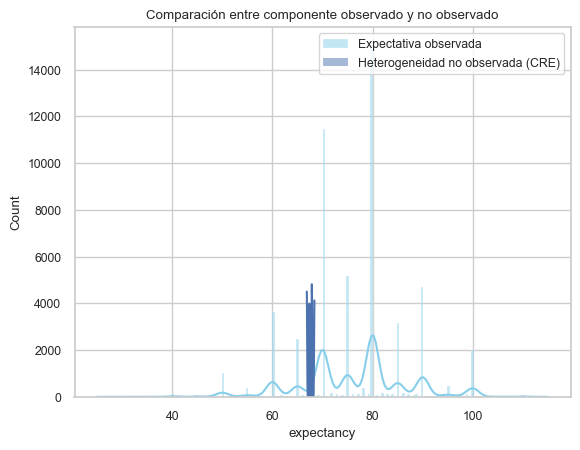

In [109]:

Xpred = df[['hombre', 'edu', 'status', 'kids', 'situation', 'exp', 'occupation',
            'wage', 'sistema', 'cotizando', 'assets', 'exp_sist', 'cronica']]
Xpred = pd.get_dummies(Xpred, columns=['status', 'situation', 'occupation', 'sistema'], drop_first=True)

for col in ['wage', 'assets', 'exp', 'exp_sist', 'edu', 'cotizando', 'cronica']:
    if col in Xpred.columns:
        Xpred[col] = 0

for col in Xpred.columns:
    if col.startswith(('status_', 'situation_', 'occupation_', 'sistema_')):
        Xpred[col] = 0

Xpred = sm.add_constant(Xpred, has_constant='add')
for col in cre.model.exog.vars:
    if col not in Xpred.columns:
        Xpred[col] = 0
Xpred = Xpred[cre.model.exog.vars]

Xpred.index = df.index
Xpred = Xpred.astype(float)

yhat_unobserved = cre.predict(Xpred)


sns.histplot(data=y, color="skyblue", label="Expectativa observada", kde=True)
sns.histplot(data=yhat_unobserved, color="red", label="Heterogeneidad no observada (CRE)", kde=True)
plt.title("Comparación entre componente observado y no observado")
plt.legend()
plt.show()


In [110]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 51561             51561             35738
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0209            0.2863            0.3104
R-Squared (Within)              0.0209            0.0070            0.0142
R-Squared (Between)            -0.2556            0.0992            0.1003
R-Squared (Overall)            -0.1527            0.0632            0.0733
F-statistic                     63.264            765.58            267.64
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

In [ ]:
common_index = y.index.intersection(yhat_unobserved.index)

y_observed_common = y.loc[common_index].squeeze()
y_unobserved_common = yhat_unobserved.loc[common_index].squeeze()

from scipy.stats import pearsonr
corr, p_value = pearsonr(y_observed_common, y_unobserved_common)

print(f"Correlación entre expectativa observada y heterogeneidad no observada (CRE): {corr:.4f}")
print(f"P-valor: {p_value:.4e}")




Correlación entre expectativa observada y heterogeneidad no observada (CRE): -0.0134
P-valor: 1.9297e-03


8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

R: El modelo CRE es el más adecuado para capturar la relación entre las variables explicativas y la expectativa de vida, ya que tiene un R² overall de 0.0733, superior al modelo de efectos fijos (FE) y al modelo de efectos aleatorios estándar (RE), lo que indica mejor capacidad explicativa. Además,  diferencia del modelo pooled o el RE estándar, el CRE incorpora promedios individuales de las variables para controlar por correlación entre efectos individuales y regresores, permitiendo una estimación no sesgada. Finalmente el test de Hausman indicó que sí existe correlación entre los efectos no observados y las covariables, por lo tanto, modelos como pooled OLS o RE simple no serían apropiados.

Sobre el efecto de las variables se pueden inferir varias cosas: 

- Las variables laborales como 'exp' y 'cotizando' tienen un efecto positivo sobre la expectativa de vida. Esto sugiere que una mayor inserción laboral se asocia a mejor salud o estabilidad.

- Variables de salud, como la presencia de una enfermedad crónica, tienen un efecto negativo y significativo, lo cual es esperable. 

- Si bien 'edu' y 'assets' no fueron tan significativos, sus promedios si lo fueron. Esto podría interpretarse como que el entorno promedio de cada individuo es más importante que las condiciones individuales. 